In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Reading CSV file
df = pd.read_csv('/content/penguins.csv')
df

,species,island,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,gender,year
0,Adelie,Torgersen,6563,11,39.1,18.7,181.0,3750.0,male,2007.0
1,Adelie,Torgersen,4890,14,39.5,17.4,186.0,3800.0,female,2007.0
2,Adelie,Torgersen,7184,11,40.3,18.0,195.0,3250.0,female,2007.0
3,Adelie,Torgersen,4169,8,NaN,NaN,NaN,992.0,NaN,2007.0
4,Adelie,Torgersen,4774,8,36.7,19.3,193.0,3450.0,female,2007.0
...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,4826,11,55.8,19.8,207.0,4000.0,male,2009.0
340,Chinstrap,Dream,4111,9,43.5,18.1,202.0,3400.0,female,2009.0
341,Chinstrap,Dream,7049,10,49.6,18.2,193.0,3775.0,male,2009.0
342,Chinstrap,Dream,4705,7,50.8,19.0,210.0,4100.0,male,2009.0


In [ ]:
#Reusing from my Assignment 0 submission
df.describe()

,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,344.000000,337.000000,333.000000,336.000000,339.000000,342.000000
mean,5270.002907,10.447674,45.494214,18.018318,197.764881,4175.463127,2008.035088
std,1067.959116,2.265895,10.815787,9.241384,27.764491,858.713267,0.816938
min,3504.000000,7.000000,32.100000,13.100000,10.000000,882.000000,2007.000000
25%,4403.000000,9.000000,39.500000,15.700000,190.000000,3550.000000,2007.000000
50%,5106.500000,10.000000,45.100000,17.300000,197.000000,4050.000000,2008.000000
75%,6212.750000,12.000000,49.000000,18.700000,213.000000,4750.000000,2009.000000
max,7197.000000,14.000000,124.300000,127.260000,231.000000,6300.000000,2009.000000


In [ ]:
#Missing values
missing_percentage = df.isnull().sum() / len(df) * 100
missing_percentage

,0
species,3.197674
island,2.906977
calorie requirement,0.000000
average sleep duration,0.000000
bill_length_mm,2.034884
bill_depth_mm,3.197674
flipper_length_mm,2.325581
body_mass_g,1.453488
gender,4.941860
year,0.581395


In [ ]:
# Checking how many rows I might need to delete with atleast one attribute missing
missing_rows_count = df.isnull().any(axis=1).sum()

missing_percentage_total = (missing_rows_count / len(df)) * 100
missing_percentage_total

11.337209302325581

In [ ]:
df = df.dropna(how='any',axis=0)
df

,species,island,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,gender,year
0,Adelie,Torgersen,6563,11,39.1,18.7,181.0,3750.0,male,2007.0
1,Adelie,Torgersen,4890,14,39.5,17.4,186.0,3800.0,female,2007.0
2,Adelie,Torgersen,7184,11,40.3,18.0,195.0,3250.0,female,2007.0
4,Adelie,Torgersen,4774,8,36.7,19.3,193.0,3450.0,female,2007.0
5,Adelie,Torgersen,4403,13,39.3,20.6,190.0,3650.0,male,2007.0
...,...,...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,4826,11,55.8,19.8,207.0,4000.0,male,2009.0
340,Chinstrap,Dream,4111,9,43.5,18.1,202.0,3400.0,female,2009.0
341,Chinstrap,Dream,7049,10,49.6,18.2,193.0,3775.0,male,2009.0
342,Chinstrap,Dream,4705,7,50.8,19.0,210.0,4100.0,male,2009.0


In [ ]:
#Standardizing columns with string values to lower case
df['species'] = df['species'].str.lower()
df['island'] = df['island'].str.lower()
df['gender'] = df['gender'].str.lower()
df

,species,island,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,gender,year
0,adelie,torgersen,6563,11,39.1,18.7,181.0,3750.0,male,2007.0
1,adelie,torgersen,4890,14,39.5,17.4,186.0,3800.0,female,2007.0
2,adelie,torgersen,7184,11,40.3,18.0,195.0,3250.0,female,2007.0
4,adelie,torgersen,4774,8,36.7,19.3,193.0,3450.0,female,2007.0
5,adelie,torgersen,4403,13,39.3,20.6,190.0,3650.0,male,2007.0
...,...,...,...,...,...,...,...,...,...,...
339,chinstrap,dream,4826,11,55.8,19.8,207.0,4000.0,male,2009.0
340,chinstrap,dream,4111,9,43.5,18.1,202.0,3400.0,female,2009.0
341,chinstrap,dream,7049,10,49.6,18.2,193.0,3775.0,male,2009.0
342,chinstrap,dream,4705,7,50.8,19.0,210.0,4100.0,male,2009.0


In [ ]:
#Removing outliers using IQR method
columns = ['average sleep duration', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'calorie requirement']
df_filtered = df  #copying dataset so that I don't end up changing the original dataset
for column in columns:
  # calculate interquartile range
  q25 = df[column].quantile(0.25)
  q75 = df[column].quantile(0.75)
  iqr = q75 - q25
  cut_off = iqr * 1.5  #using a generous multiple of 1.5 since it is a small dataset
  lower, upper = q25 - cut_off, q75 + cut_off
  print("Removing values in " + column + " < "+ str(lower) + " and > " + str(upper))
  df_filtered = df_filtered[(df_filtered[column] < upper) & (df_filtered[column] > lower)]

Removing values in average sleep duration < 4.5 and > 16.5
Removing values in bill_length_mm < 25.699999999999996 and > 62.50000000000001
Removing values in bill_depth_mm < 11.2 and > 23.2
Removing values in flipper_length_mm < 155.5 and > 247.5
Removing values in body_mass_g < 1712.5 and > 6612.5
Removing values in calorie requirement < 1734.5 and > 8890.5


In [ ]:
df_filtered

,species,island,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,gender,year
0,adelie,torgersen,6563,11,39.1,18.7,181.0,3750.0,male,2007.0
1,adelie,torgersen,4890,14,39.5,17.4,186.0,3800.0,female,2007.0
2,adelie,torgersen,7184,11,40.3,18.0,195.0,3250.0,female,2007.0
4,adelie,torgersen,4774,8,36.7,19.3,193.0,3450.0,female,2007.0
5,adelie,torgersen,4403,13,39.3,20.6,190.0,3650.0,male,2007.0
...,...,...,...,...,...,...,...,...,...,...
339,chinstrap,dream,4826,11,55.8,19.8,207.0,4000.0,male,2009.0
340,chinstrap,dream,4111,9,43.5,18.1,202.0,3400.0,female,2009.0
341,chinstrap,dream,7049,10,49.6,18.2,193.0,3775.0,male,2009.0
342,chinstrap,dream,4705,7,50.8,19.0,210.0,4100.0,male,2009.0


Only ended up removing 5 rows for outlier treatment using the IQR method.

In [ ]:
df.describe()

,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000
mean,5275.659016,10.508197,44.311541,17.562492,199.055738,4202.622951,2008.042623
std,1064.219767,2.233293,7.123057,6.598977,23.106451,807.439507,0.816052
min,3504.000000,7.000000,32.100000,13.100000,10.000000,2700.000000,2007.000000
25%,4418.000000,9.000000,39.500000,15.700000,190.000000,3550.000000,2007.000000
50%,5105.000000,10.000000,44.100000,17.500000,197.000000,4050.000000,2008.000000
75%,6207.000000,12.000000,48.700000,18.700000,213.000000,4775.000000,2009.000000
max,7197.000000,14.000000,112.750000,127.260000,231.000000,6300.000000,2009.000000


#Visualizations

species
adelie       136
chinstrap     59
gentoo       105
Name: species, dtype: int64


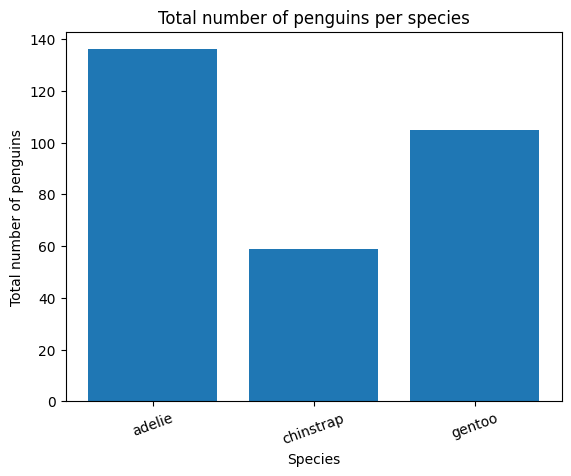

In [ ]:
#Plotting total number of penguins per species (from Assignment 0)
penguin_types = df_filtered.groupby('species')['species'].count()
plt.bar(penguin_types.index, penguin_types.values)
plt.title("Total number of penguins per species")
plt.xlabel("Species")
plt.ylabel("Total number of penguins")
plt.xticks(rotation=20)
print(penguin_types)

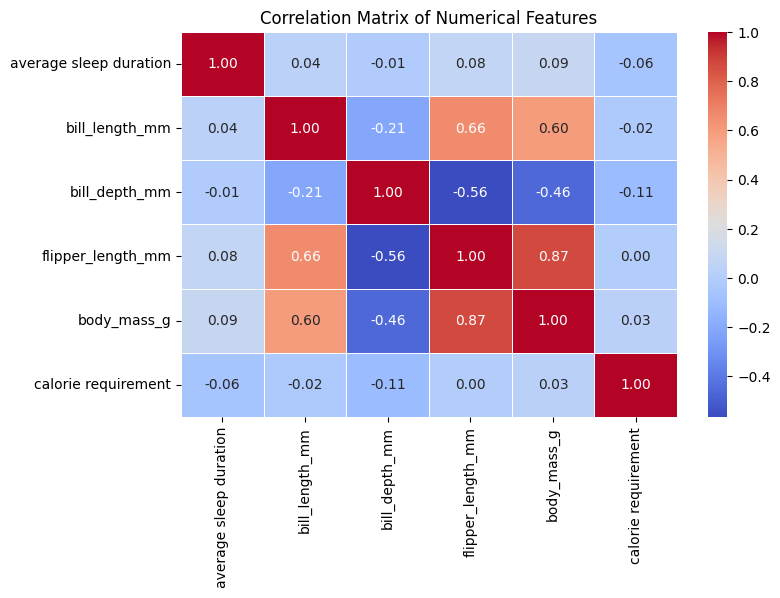

In [ ]:
# Heatmap of correlations between numerical features
plt.figure(figsize=(8, 5))
correlation_matrix = df_filtered[columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

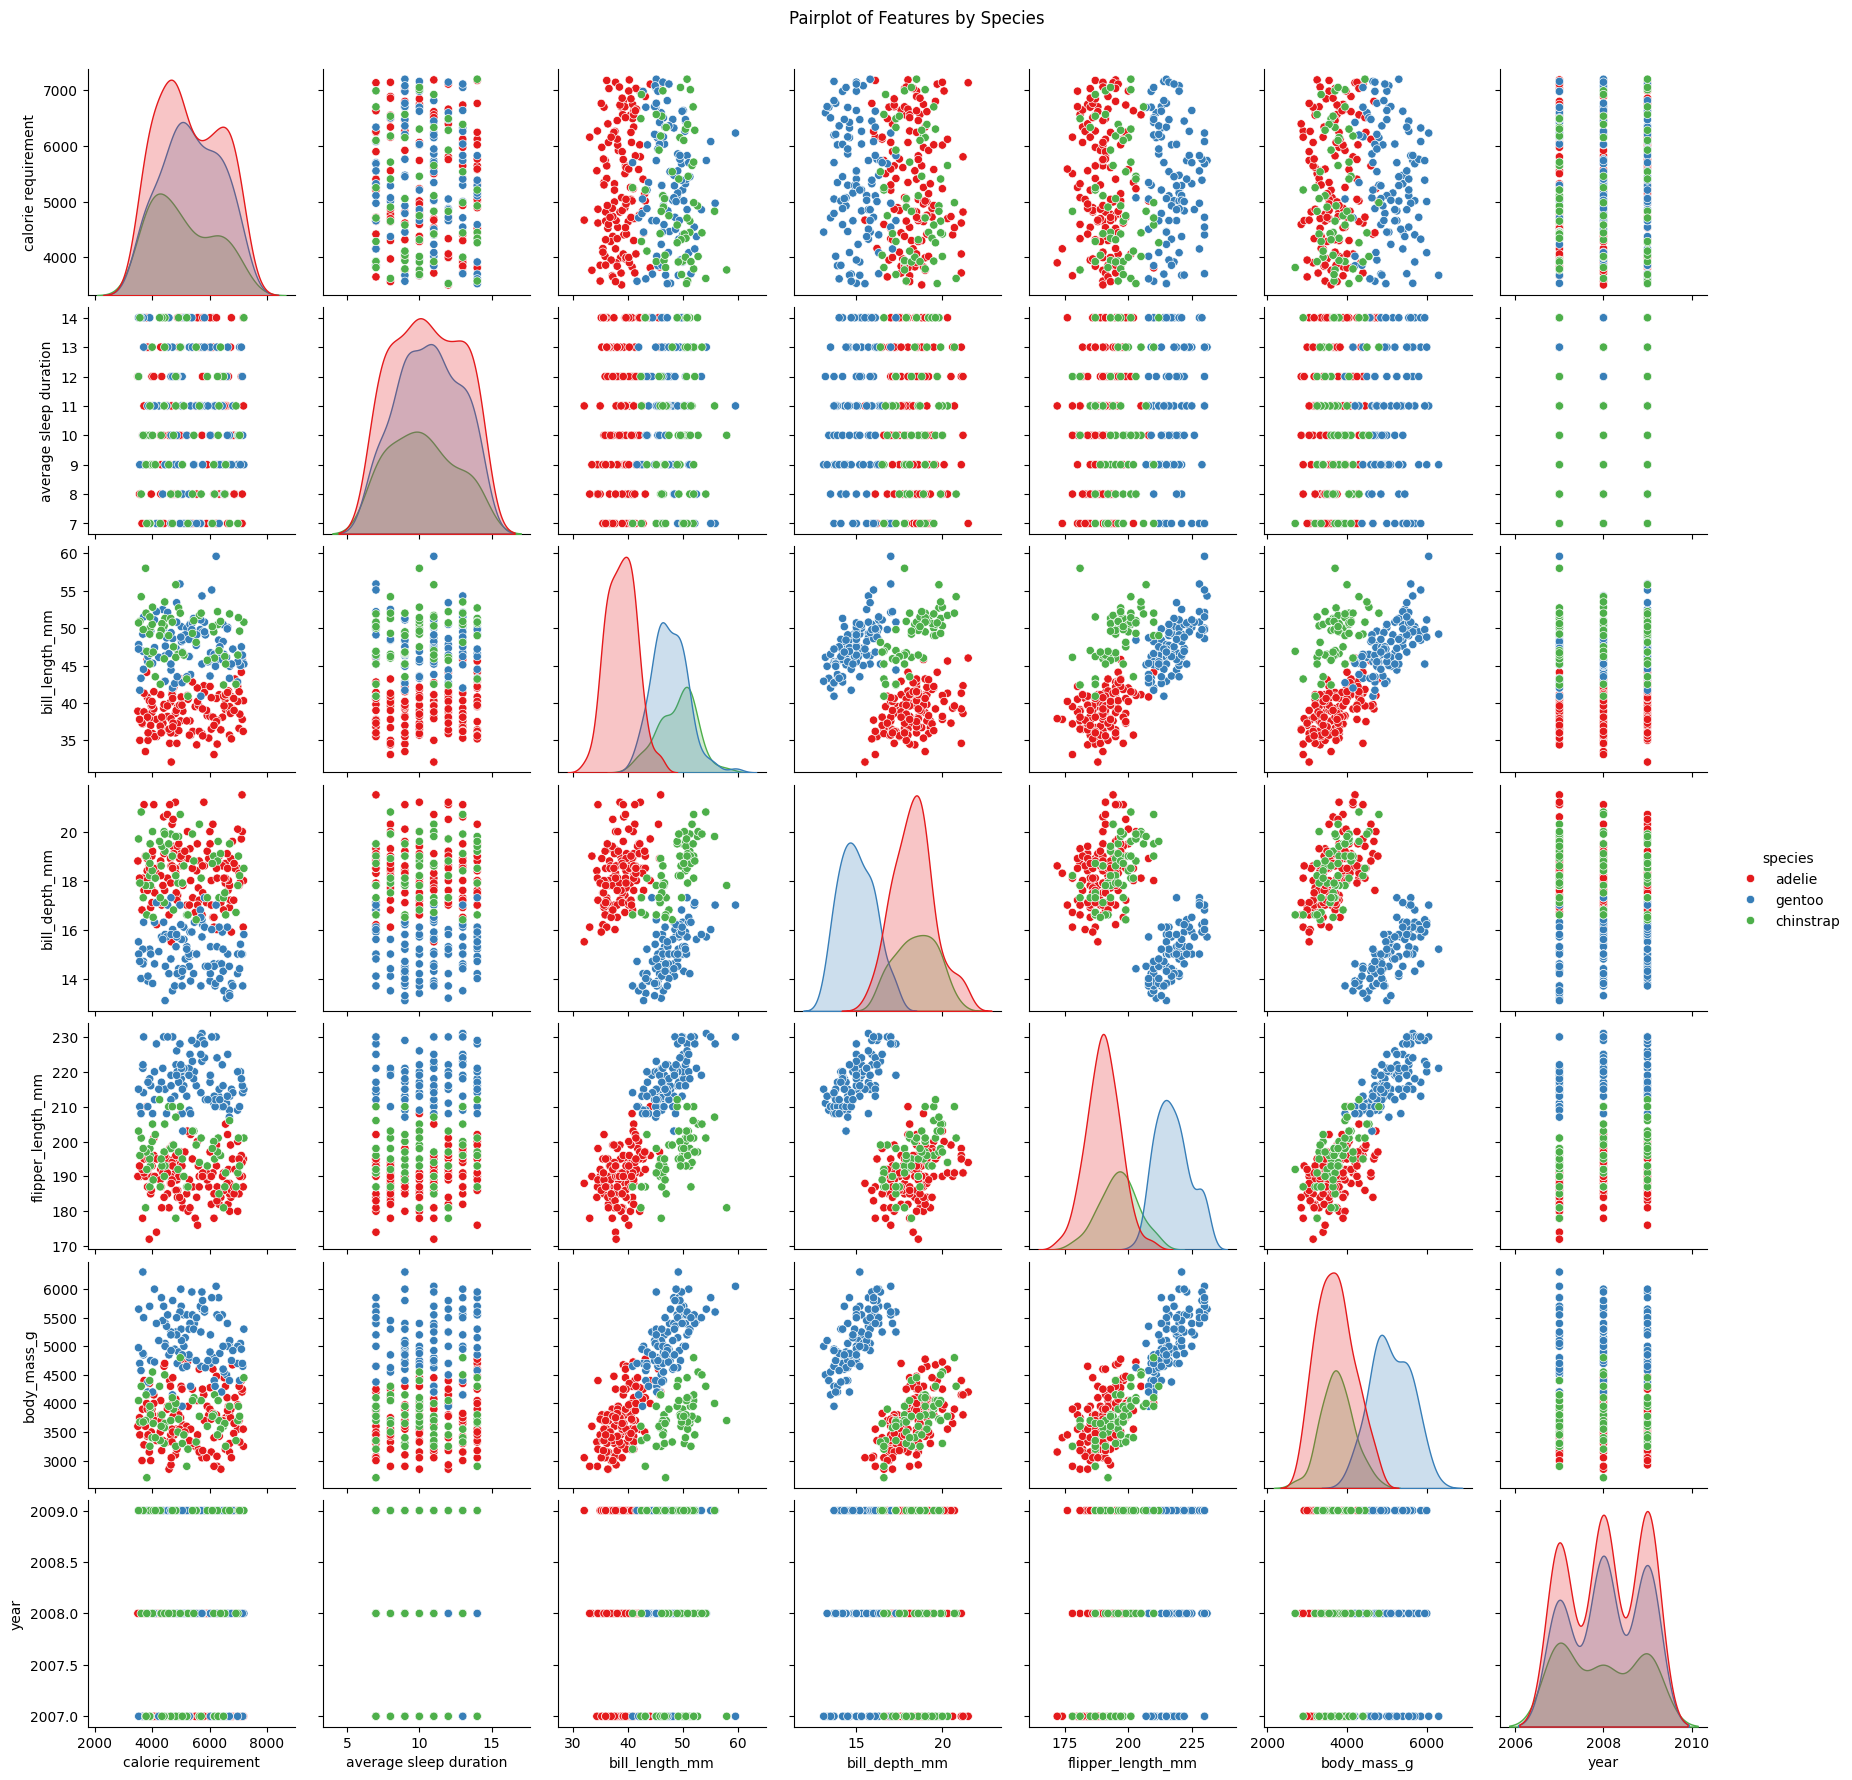

In [ ]:
#Pairplot to visualize relationships between features
sns.pairplot(df_filtered, hue='species', palette='Set1')
plt.suptitle('Pairplot of Features by Species', y=1.02)
plt.show()

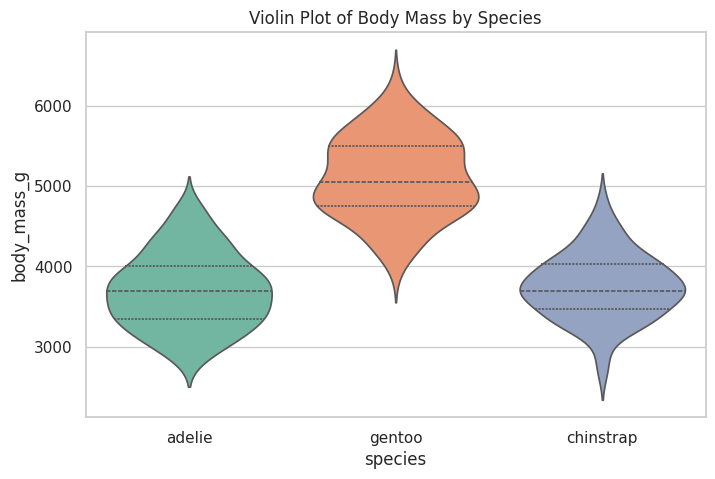

In [ ]:
#Viloin plot to visualize body mass ranges wrt different species
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.violinplot(x='species', y='body_mass_g', data=df_filtered, palette='Set2', inner='quartile')
plt.title('Violin Plot of Body Mass by Species')
plt.ylabel('body_mass_g')
plt.xlabel('species')
plt.show()

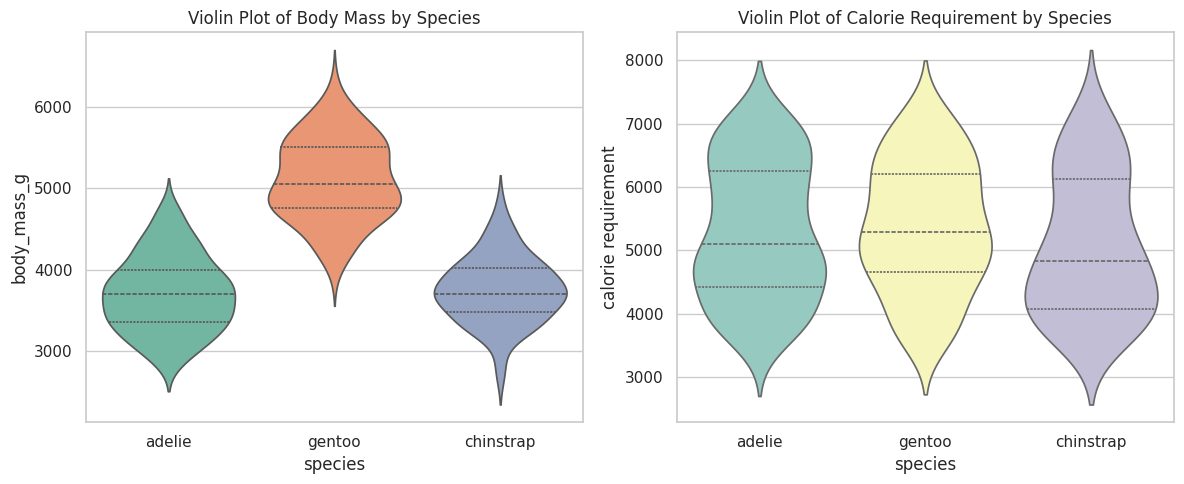

In [ ]:
#Violin plot to visualize if higher body mass translates to higher calorie requirement
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x='species', y='body_mass_g', data=df_filtered, palette='Set2', inner='quartile')
plt.title('Violin Plot of Body Mass by Species')
plt.ylabel('body_mass_g')
plt.xlabel('species')

plt.subplot(1, 2, 2)
sns.violinplot(x='species', y='calorie requirement', data=df_filtered, palette='Set3', inner='quartile')
plt.title('Violin Plot of Calorie Requirement by Species')
plt.ylabel('calorie requirement')
plt.xlabel('species')

plt.tight_layout()
plt.show()

#Converting string to categorical and normalizing numerical

In [ ]:
#Reusing my code from Assignment 0

#species
species_categorical = pd.Categorical(df_filtered['species'])
df_filtered['species_categorical'] = species_categorical.codes
df_filtered.drop('species', axis=1, inplace=True)

#island
island_categorical = pd.Categorical(df_filtered['island'])
df_filtered['island_categorical'] = island_categorical.codes
df_filtered.drop('island', axis=1, inplace=True)

#gender
gender_categorical = pd.Categorical(df_filtered['gender'])
df_filtered['gender_categorical'] = gender_categorical.codes
df_filtered.drop('gender', axis=1, inplace=True)

df_filtered

,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_categorical,island_categorical,gender_categorical
0,6563,11,39.1,18.7,181.0,3750.0,2007.0,0,2,1
1,4890,14,39.5,17.4,186.0,3800.0,2007.0,0,2,0
2,7184,11,40.3,18.0,195.0,3250.0,2007.0,0,2,0
4,4774,8,36.7,19.3,193.0,3450.0,2007.0,0,2,0
5,4403,13,39.3,20.6,190.0,3650.0,2007.0,0,2,1
...,...,...,...,...,...,...,...,...,...,...
339,4826,11,55.8,19.8,207.0,4000.0,2009.0,1,1,1
340,4111,9,43.5,18.1,202.0,3400.0,2009.0,1,1,0
341,7049,10,49.6,18.2,193.0,3775.0,2009.0,1,1,1
342,4705,7,50.8,19.0,210.0,4100.0,2009.0,1,1,1


In [ ]:
#Reusing my code from Assignment 0
columns = ['average sleep duration', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'calorie requirement']
for column in columns:
  max = df_filtered[column].max()
  min = df_filtered[column].min()
  df_filtered[column] = (df_filtered[column] - min) / (max - min)

df_filtered

,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_categorical,island_categorical,gender_categorical
0,0.828324,0.571429,0.254545,0.666667,0.152542,0.291667,2007.0,0,2,1
1,0.375305,1.000000,0.269091,0.511905,0.237288,0.305556,2007.0,0,2,0
2,0.996480,0.571429,0.298182,0.583333,0.389831,0.152778,2007.0,0,2,0
4,0.343894,0.142857,0.167273,0.738095,0.355932,0.208333,2007.0,0,2,0
5,0.243434,0.857143,0.261818,0.892857,0.305085,0.263889,2007.0,0,2,1
...,...,...,...,...,...,...,...,...,...,...
339,0.357975,0.571429,0.861818,0.797619,0.593220,0.361111,2009.0,1,1,1
340,0.164365,0.285714,0.414545,0.595238,0.508475,0.194444,2009.0,1,1,0
341,0.959924,0.428571,0.636364,0.607143,0.355932,0.298611,2009.0,1,1,1
342,0.325210,0.000000,0.680000,0.702381,0.644068,0.388889,2009.0,1,1,1


#Checking and dropping features with low correlation to the target column

In [ ]:
correlation_matrix = pd.DataFrame.corr(df_filtered)
correlation_matrix

,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_categorical,island_categorical,gender_categorical
calorie requirement,1.000000,-0.059755,-0.021892,-0.110745,0.000310,0.029097,-0.014883,0.023041,-0.032394,-0.007381
average sleep duration,-0.059755,1.000000,0.039900,-0.009787,0.076351,0.091462,0.019935,0.013263,0.000865,0.078985
bill_length_mm,-0.021892,0.039900,1.000000,-0.213336,0.659096,0.600925,0.039329,0.730771,-0.323034,0.368319
bill_depth_mm,-0.110745,-0.009787,-0.213336,1.000000,-0.564339,-0.461764,-0.053891,-0.730484,0.547130,0.375190
flipper_length_mm,0.000310,0.076351,0.659096,-0.564339,1.000000,0.871576,0.164676,0.850955,-0.543618,0.269758
body_mass_g,0.029097,0.091462,0.600925,-0.461764,0.871576,1.000000,0.033118,0.753427,-0.546300,0.436215
year,-0.014883,0.019935,0.039329,-0.053891,0.164676,0.033118,1.000000,0.010336,-0.061988,0.015449
species_categorical,0.023041,0.013263,0.730771,-0.730484,0.850955,0.753427,0.010336,1.000000,-0.603556,0.028535
island_categorical,-0.032394,0.000865,-0.323034,0.547130,-0.543618,-0.546300,-0.061988,-0.603556,1.000000,-0.018141
gender_categorical,-0.007381,0.078985,0.368319,0.375190,0.269758,0.436215,0.015449,0.028535,-0.018141,1.000000


Our choice of target variable for this dataset is "gender_categorical" or GENDER

In [ ]:
target_corr = correlation_matrix['gender_categorical']
target_corr

,gender_categorical
calorie requirement,-0.007381
average sleep duration,0.078985
bill_length_mm,0.368319
bill_depth_mm,0.375190
flipper_length_mm,0.269758
body_mass_g,0.436215
year,0.015449
species_categorical,0.028535
island_categorical,-0.018141
gender_categorical,1.000000


Generally, we choose the threshold as 0.1 but we might lose out on a lot of features that way. Thus, for this case, I am choosing a conservative value of 0.01

In [ ]:
correlation_threshold = 0.02
features_dropped = target_corr[target_corr.abs() < correlation_threshold].index.tolist()
final_df = df_filtered.drop(columns=features_dropped)
final_df

,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_categorical,gender_categorical
0,0.571429,0.254545,0.666667,0.152542,0.291667,0,1
1,1.000000,0.269091,0.511905,0.237288,0.305556,0,0
2,0.571429,0.298182,0.583333,0.389831,0.152778,0,0
4,0.142857,0.167273,0.738095,0.355932,0.208333,0,0
5,0.857143,0.261818,0.892857,0.305085,0.263889,0,1
...,...,...,...,...,...,...,...
339,0.571429,0.861818,0.797619,0.593220,0.361111,1,1
340,0.285714,0.414545,0.595238,0.508475,0.194444,1,0
341,0.428571,0.636364,0.607143,0.355932,0.298611,1,1
342,0.000000,0.680000,0.702381,0.644068,0.388889,1,1


In [ ]:
final_df.to_csv('penguins_preprocessed.csv', index=False, header=True)

In [ ]:
#Reusing from my Assignment 0 submission
final_df.describe()

,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_categorical,gender_categorical
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.501905,0.430339,0.488135,0.489096,0.418264,0.896667,0.510000
std,0.319646,0.201221,0.233649,0.239595,0.224550,0.891800,0.500735
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.285714,0.260909,0.309524,0.305085,0.236111,0.000000,0.000000
50%,0.428571,0.430909,0.505952,0.423729,0.375000,1.000000,1.000000
75%,0.714286,0.600909,0.666667,0.694915,0.578125,2.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000


#References

In [ ]:
#https://stackoverflow.com/questions/51070985/find-out-the-percentage-of-missing-values-in-each-column-in-the-given-dataset
#https://machinelearningmastery.com/how-to-use-statistics-to-identify-outliers-in-data/
#https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html